In [1]:
import os
os.environ['R_HOME'] = '/home/yanxh/anaconda3/envs/R4.3/lib/R'
os.environ['R_USER'] = '/home/yanxh/anaconda3/envs/R4.3/lib/python3.8/site-packages/rpy2'
import psutil

# Get the current process
# p = psutil.Process(os.getpid())

# # Set the process to run only on the first CPU core
# p.cpu_affinity([5])

In [2]:
import os
import gc
import pandas as pd
import pickle
import matplotlib.pyplot as plt

import anndata as ad
import numpy as np
import yaml
import sys
import h5py
import logging
import scanpy as sc
from os.path import join
import scipy.sparse as sps
from sklearn.cluster import KMeans

import scglue

import warnings
def wrap_warn_plot(adata, basis, color, **kwargs):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        sc.pl.embedding(adata, basis=basis, color=color, **kwargs)

def get_umap(ad, use_reps=[]):
    for use_rep in use_reps:
        umap_add_key = f'{use_rep}_umap'
        sc.pp.neighbors(ad, use_rep=use_rep, n_neighbors=15)
        sc.tl.umap(ad)
        ad.obsm[umap_add_key] = ad.obsm['X_umap']
    return ad

from sklearn.metrics import adjusted_rand_score

def split_ob(ads, ad_ref, ob='obs', key='emb2'):
    len_ads = [_.n_obs for _ in ads]
    if ob=='obsm':
        split_obsms = np.split(ad_ref.obsm[key], np.cumsum(len_ads[:-1]))
        for ad, v in zip(ads, split_obsms):
            ad.obsm[key] = v
    else:
        split_obs = np.split(ad_ref.obs[key].to_list(), np.cumsum(len_ads[:-1]))
        for ad, v in zip(ads, split_obs):
            ad.obs[key] = v

def eval_ads(ads, ref_key, src_key):
    aris = []
    for ad in ads:
        aris.append(adjusted_rand_score(ad.obs[src_key], ad.obs[ref_key]))
    return aris


def flip_coords(ads):
    for ad in ads:
        ad.obsm['spatial'] = -1 * ad.obsm['spatial']
        ad.obsm['spatial'] = ad.obsm['spatial'][:, ::-1]

def reorder(ad1, ad2):
    shared_barcodes = ad1.obs_names.intersection(ad2.obs_names)
    ad1 = ad1[shared_barcodes].copy()
    ad2 = ad2[shared_barcodes].copy()
    return ad1, ad2

def load_peak_expr(_dir):
    data = sio.mmread(join(_dir, 'data.mtx'))
    cname = pd.read_csv(join(_dir, 'barcode.csv'), index_col=0)['x'].to_list()
    feat = pd.read_csv(join(_dir, 'feat.csv'), index_col=0)['x'].to_list()
    ad = sc.AnnData(sps.csr_matrix(data.T))
    ad.obs_names = cname
    ad.var_names = feat
    return ad

/home/yanxh/anaconda3/envs/torch112/lib/python3.8/site-packages/setuptools_scm/_integration/setuptools.py:30: RuntimeWarning: 
ERROR: setuptools==59.5.0 is used in combination with setuptools_scm>=8.x

Your build configuration is incomplete and previously worked by accident!
setuptools_scm requires setuptools>=61

Suggested workaround if applicable:
 - migrating from the deprecated setup_requires mechanism to pep517/518
   and using a pyproject.toml to declare build dependencies
   which are reliably pre-installed before running the build tools

  warnings.warn(


In [3]:
def set_col2cat(ad, cols=[]):
    for col in cols:
        ad.obs[col] = ad.obs[col].astype('category')

def unify_colors(queries, color_key, ref_color_dict):
    for q in queries:
        q.obs[color_key] = q.obs[color_key].astype('category')
        q.uns[f'{color_key}_colors'] = [ref_color_dict[_] for _ in q.obs[color_key].cat.categories]
    return queries

def subset_ad(ad, subset_index):
    ad = ad[subset_index].copy()
    return ad

### Training and running

In [4]:
sys.path.insert(0, './resources')
import utils
import scipy.io as sio

In [5]:
out_dir = './cache/Embryo'
os.makedirs(out_dir, exist_ok=True)
## best setting for simulation experiments
# n_genes = 10000
# x2u_h_depth = 2
# x2u_h_dim = 512 
# u2x_h_depth = 1
# du_h_depth = 2
# dropout = 0.2
# lam_data = 1.0
# lam_kl = 1.0  
# lam_align = 2.0   
# lam_cross = 2.0 
# lam_cos = 1.0 
# normalize_u = True
# random_seed = 5
# latent_dim = 50
# u2x_h_dim = 256
# du_h_dim  = u2x_h_dim
# du_h_depth = 2

## multiome setting
n_genes = 10000
latent_dim = 50
x2u_h_depth = 2
x2u_h_dim = 512
u2x_h_depth = 1
u2x_h_dim = 256
du_h_depth = 1
du_h_dim = 256
dropout = 0.2
lam_data = 1.0
lam_kl = 0.3
lam_align = 0.02
lam_cross = 1.0
lam_cos = 0.02
normalize_u = True
random_seed = 2

max_epochs1 = 400
max_epochs2 = 50

In [6]:
data_dir = '../../../data/processed/Embryo'

ad_sra_rna = sc.read_h5ad(join(data_dir, 'SRA/ad_rna.h5ad'))
ad_sra_atac = sc.read_h5ad(join(data_dir, 'SRA/ad_atac.h5ad'))

ad_mux2_27ac = sc.read_h5ad(join(data_dir, 'Mux2/ad_h3k27ac.h5ad'))
ad_mux2_27me = sc.read_h5ad(join(data_dir, 'Mux2/ad_h3k27me3.h5ad'))

ad_mux4_rna = sc.read_h5ad(join(data_dir, 'Mux4/ad_rna.h5ad'))
ad_mux4_atac = sc.read_h5ad(join(data_dir, 'Mux4/ad_atac.h5ad'))
ad_mux4_4me3 = sc.read_h5ad(join(data_dir, 'Mux4/ad_h3k4me3.h5ad'))
ad_mux4_27me = sc.read_h5ad(join(data_dir, 'Mux4/ad_h3k27me3.h5ad'))

ad_sat_atac = sc.read_h5ad(join(data_dir, 'SAT/ad_atac.h5ad'))
ad_cut_27ac = sc.read_h5ad(join(data_dir, 'Cut-H3K27ac/ad_h3k27ac.h5ad'))
ad_cut_4me3 = sc.read_h5ad(join(data_dir, 'Cut-H3K4me3/ad_h3k4me3.h5ad'))
ad_cut_27me = sc.read_h5ad(join(data_dir, 'Cut-H3K27me3/ad_h3k27me3.h5ad'))

In [7]:
ad_rna_all = sc.concat([ad_sra_rna, ad_mux4_rna])
sc.pp.highly_variable_genes(ad_rna_all, flavor='seurat_v3', n_top_genes=10000, batch_key='Slice')
hvg_names = ad_rna_all.var.query('highly_variable').index.to_numpy()

ad_atac_all = sc.concat([ad_sra_atac, ad_mux4_atac, ad_sat_atac])
sc.pp.highly_variable_genes(ad_atac_all, flavor='seurat_v3', n_top_genes=100000, batch_key='Slice')
hvp_names = ad_atac_all.var.query('highly_variable').index.to_numpy()

ad_27me_all = sc.concat([ad_mux2_27me, ad_mux4_27me, ad_cut_27me])
sc.pp.highly_variable_genes(ad_27me_all, flavor='seurat_v3', n_top_genes=100000, batch_key='Slice')
hv27me_names = ad_27me_all.var.query('highly_variable').index.to_numpy()

ad_4me3_all = sc.concat([ad_mux4_4me3, ad_cut_4me3])
sc.pp.highly_variable_genes(ad_4me3_all, flavor='seurat_v3', n_top_genes=100000, batch_key='Slice')
hv4me3_names = ad_4me3_all.var.query('highly_variable').index.to_numpy()

ad_27ac_all = sc.concat([ad_mux2_27ac, ad_cut_27ac])
sc.pp.highly_variable_genes(ad_27ac_all, flavor='seurat_v3', n_top_genes=100000, batch_key='Slice')
hv27ac_names = ad_27ac_all.var.query('highly_variable').index.to_numpy()

In [8]:
ad_sra_rna = ad_sra_rna[:, hvg_names].copy()
ad_sra_atac = ad_sra_atac[:, hvp_names].copy()

ad_mux2_27ac = ad_mux2_27ac[:, hv27ac_names].copy()
ad_mux2_27me = ad_mux2_27me[:, hv27me_names].copy()

ad_mux4_rna = ad_mux4_rna[:, hvg_names].copy()
ad_mux4_atac = ad_mux4_atac[:, hvp_names].copy()
ad_mux4_4me3 = ad_mux4_4me3[:, hv4me3_names].copy()
ad_mux4_27me = ad_mux4_27me[:, hv27me_names].copy()

ad_sat_atac = ad_sat_atac[:, hvp_names].copy()
ad_cut_27ac = ad_cut_27ac[:, hv27ac_names].copy()
ad_cut_4me3 = ad_cut_4me3[:, hv4me3_names].copy()
ad_cut_27me = ad_cut_27me[:, hv27me_names].copy()

In [9]:
ad_train_rna = sc.concat([ad_sra_rna, ad_mux4_rna])
ad_train_atac = sc.concat([ad_sra_atac, ad_mux4_atac])
ad_train_27me = sc.concat([ad_mux2_27me, ad_mux4_27me])
ad_train_27ac = ad_mux2_27ac.copy()
ad_train_4me3 = ad_mux4_4me3.copy()
ad_train_rna.layers['counts'] = sps.csr_matrix(ad_train_rna.X)
ad_train_atac.layers['counts'] = sps.csr_matrix(ad_train_atac.X)
ad_train_27ac.layers['counts'] = sps.csr_matrix(ad_train_27ac.X)
ad_train_4me3.layers['counts'] = sps.csr_matrix(ad_train_4me3.X)
ad_train_27me.layers['counts'] = sps.csr_matrix(ad_train_27me.X)

ad_sat_atac.layers['counts'] = sps.csr_matrix(ad_sat_atac.X)
ad_cut_27ac.layers['counts'] = sps.csr_matrix(ad_cut_27ac.X)
ad_cut_4me3.layers['counts'] = sps.csr_matrix(ad_cut_4me3.X)
ad_cut_27me.layers['counts'] = sps.csr_matrix(ad_cut_27me.X)

ad_train_rna.obs["uid"] = [f"train-{nm}" for nm in ad_train_rna.obs_names]
ad_train_atac.obs["uid"] = [f"train-{nm}" for nm in ad_train_atac.obs_names]
ad_train_27me.obs["uid"] = [f"train-{nm}" for nm in ad_train_27me.obs_names]
ad_train_27ac.obs["uid"] = [f"train-{nm}" for nm in ad_train_27ac.obs_names]
ad_train_4me3.obs["uid"] = [f"train-{nm}" for nm in ad_train_4me3.obs_names]

ad_sat_atac.obs["uid"] = [f"test-{nm}" for nm in ad_sat_atac.obs_names]
ad_cut_27ac.obs["uid"] = [f"test-{nm}" for nm in ad_cut_27ac.obs_names]
ad_cut_4me3.obs["uid"] = [f"test-{nm}" for nm in ad_cut_4me3.obs_names]
ad_cut_27me.obs["uid"] = [f"test-{nm}" for nm in ad_cut_27me.obs_names]

ad_train_rna.obs['batch'] = ad_train_rna.obs['Slice'].to_list()
ad_train_atac.obs['batch'] = ad_train_atac.obs['Slice'].to_list()
ad_train_27me.obs['batch'] = ad_train_27me.obs['Slice'].to_list()
ad_train_27ac.obs['batch'] = ad_train_27ac.obs['Slice'].to_list()
ad_train_4me3.obs['batch'] = ad_train_4me3.obs['Slice'].to_list()

ad_sat_atac.obs['batch'] = ad_sat_atac.obs['Slice'].to_list()
ad_cut_27ac.obs['batch'] = ad_cut_27ac.obs['Slice'].to_list()
ad_cut_4me3.obs['batch'] = ad_cut_4me3.obs['Slice'].to_list()
ad_cut_27me.obs['batch'] = ad_cut_27me.obs['Slice'].to_list()


In [10]:
print('Reading `h5ad` files...')
omics = "multiome"

Reading `h5ad` files...


In [11]:
print('Preprocessing GEX...')
gex_prep = utils.GEXPreprocessing(n_comps=100, n_genes=n_genes, merge_adt=omics == "cite")
gex_prep.fit_transform(ad_train_rna)
print('Preprocessing ATAC...')
other_prep1 = utils.ATACPreprocessing(n_comps=100)
other_prep1.fit_transform(ad_train_atac)
print('Preprocessing H3K4me3...')
other_prep2 = utils.ATACPreprocessing(n_comps=100)
other_prep2.fit_transform(ad_train_4me3)
print('Preprocessing H3K27ac...')
other_prep3 = utils.ATACPreprocessing(n_comps=100)
other_prep3.fit_transform(ad_train_27ac)
print('Preprocessing H3K27me3...')
other_prep4 = utils.ATACPreprocessing(n_comps=100)
other_prep4.fit_transform(ad_train_27me)

with open(os.path.join(out_dir, "prep.pickle"), "wb") as f:
    pickle.dump({
        "gex_prep": gex_prep,
        "atac_prep": other_prep1,
        "h3k4me3": other_prep2,
        "h3k27ac": other_prep3,
        "h3k27me3": other_prep4
    }, f)

with open(f"{out_dir}/hyperparams.yaml", "w") as f:
    yaml.dump({
        "n_genes": n_genes,
        "latent_dim": latent_dim,
        "x2u_h_depth": x2u_h_depth,
        "x2u_h_dim": x2u_h_dim,
        "u2x_h_depth": u2x_h_depth,
        "u2x_h_dim": u2x_h_dim,
        "du_h_depth": du_h_depth,
        "du_h_dim": du_h_dim,
        "dropout": dropout,
        "lam_data": lam_data,
        "lam_kl": lam_kl,
        "lam_align": lam_align,
        "lam_cross": lam_cross,
        "lam_cos": lam_cos,
        "normalize_u": normalize_u,
        "random_seed": random_seed
    }, f)

scglue.models.configure_dataset(
    ad_train_rna, "NB", use_highly_variable=True,
    use_layer="counts", use_rep="X_pca",
    use_batch="batch", use_uid="uid"
)
scglue.models.configure_dataset(
    ad_train_atac, "NB", use_highly_variable=True,
    use_layer="counts", use_rep="X_lsi",
    use_batch="batch", use_uid="uid"
)
scglue.models.configure_dataset(
    ad_train_4me3, "NB", use_highly_variable=True,
    use_layer="counts", use_rep="X_lsi",
    use_batch="batch", use_uid="uid"
)
scglue.models.configure_dataset(
    ad_train_27ac, "NB", use_highly_variable=True,
    use_layer="counts", use_rep="X_lsi",
    use_batch="batch", use_uid="uid"
)
scglue.models.configure_dataset(
    ad_train_27me, "NB", use_highly_variable=True,
    use_layer="counts", use_rep="X_lsi",
    use_batch="batch", use_uid="uid"
)

print('Building model...')
model = scglue.models.SCCLUEModel(
    {"gex": ad_train_rna, "atac": ad_train_atac, 
     "h3k4me3": ad_train_4me3, "h3k27ac":ad_train_27ac, "h3k27me3":ad_train_27me},
    latent_dim=latent_dim,
    x2u_h_depth=x2u_h_depth,
    x2u_h_dim=x2u_h_dim,
    u2x_h_depth=u2x_h_depth,
    u2x_h_dim=u2x_h_dim,
    du_h_depth=du_h_depth,
    du_h_dim=du_h_dim,
    dropout=dropout,
    shared_batches=False,
    random_seed=random_seed
)

print('Compiling model...')
model.compile(
    lam_data=lam_data, lam_kl=lam_kl, lam_align=lam_align,
    lam_cross=lam_cross, lam_cos=lam_cos, normalize_u=normalize_u,
    domain_weight={"gex": 1, "atac": 1, "h3k4me3": 1, "h3k27ac":1, "h3k27me3":1},
)

# help(model.fit)
print('Training model...')
model.fit(
    {"gex": ad_train_rna, "atac": ad_train_atac, 
     "h3k4me3": ad_train_4me3, "h3k27ac":ad_train_27ac, "h3k27me3":ad_train_27me}, 
    max_epochs=max_epochs1,
)
model.save(os.path.join(out_dir, "pretrain.dill"))


Preprocessing GEX...
Preprocessing ATAC...
Preprocessing H3K4me3...
Preprocessing H3K27ac...
Preprocessing H3K27me3...
Building model...
[INFO] autodevice: Using GPU 1 as computation device.
Compiling model...
Training model...
[INFO] SCCLUEModel: Setting `align_burnin` = 133
[INFO] SCCLUEModel: Setting `patience` = 100
[INFO] SCCLUEModel: Setting `reduce_lr_patience` = 34
[INFO] SCCLUETrainer: Using training directory: "/tmp/GLUETMPg4jlmkfd"
[INFO] SCCLUETrainer: [Epoch 10] train={'dsc_loss': 1.507, 'gen_loss': 4.887, 'cross_loss': 2.446, 'cos_loss': 0.744, 'x_gex_nll': 0.343, 'x_gex_kl': 0.021, 'x_gex_elbo': 0.349, 'x_atac_nll': 0.336, 'x_atac_kl': 0.011, 'x_atac_elbo': 0.339, 'x_h3k4me3_nll': 0.616, 'x_h3k4me3_kl': 0.011, 'x_h3k4me3_elbo': 0.62, 'x_h3k27ac_nll': 0.509, 'x_h3k27ac_kl': 0.011, 'x_h3k27ac_elbo': 0.513, 'x_h3k27me3_nll': 0.633, 'x_h3k27me3_kl': 0.012, 'x_h3k27me3_elbo': 0.636}, val={'dsc_loss': 1.55, 'gen_loss': 4.987, 'cross_loss': 2.494, 'cos_loss': 0.69, 'x_gex_nll':

NaN or Inf found in input tensor.
NaN or Inf found in input tensor.
NaN or Inf found in input tensor.


[INFO] SCCLUETrainer: [Epoch 50] train={'dsc_loss': 1.497, 'gen_loss': 2.943, 'cross_loss': 1.475, 'cos_loss': 0.457, 'x_gex_nll': 0.238, 'x_gex_kl': 0.027, 'x_gex_elbo': 0.246, 'x_atac_nll': 0.268, 'x_atac_kl': 0.013, 'x_atac_elbo': 0.272, 'x_h3k4me3_nll': 0.342, 'x_h3k4me3_kl': 0.013, 'x_h3k4me3_elbo': 0.346, 'x_h3k27ac_nll': 0.288, 'x_h3k27ac_kl': 0.012, 'x_h3k27ac_elbo': 0.292, 'x_h3k27me3_nll': 0.329, 'x_h3k27me3_kl': 0.015, 'x_h3k27me3_elbo': 0.334}, val={'dsc_loss': 1.51, 'gen_loss': 3.144, 'cross_loss': 1.567, 'cos_loss': 0.439, 'x_gex_nll': 0.247, 'x_gex_kl': 0.027, 'x_gex_elbo': 0.255, 'x_atac_nll': 0.275, 'x_atac_kl': 0.013, 'x_atac_elbo': 0.279, 'x_h3k4me3_nll': 0.367, 'x_h3k4me3_kl': 0.012, 'x_h3k4me3_elbo': 0.371, 'x_h3k27ac_nll': 0.336, 'x_h3k27ac_kl': 0.012, 'x_h3k27ac_elbo': 0.34, 'x_h3k27me3_nll': 0.349, 'x_h3k27me3_kl': 0.015, 'x_h3k27me3_elbo': 0.353}, 9.0s elapsed
[INFO] SCCLUETrainer: [Epoch 60] train={'dsc_loss': 1.488, 'gen_loss': 2.918, 'cross_loss': 1.462, 'co

NaN or Inf found in input tensor.
NaN or Inf found in input tensor.
NaN or Inf found in input tensor.


[INFO] SCCLUETrainer: [Epoch 70] train={'dsc_loss': 1.482, 'gen_loss': 2.903, 'cross_loss': 1.455, 'cos_loss': 0.443, 'x_gex_nll': 0.233, 'x_gex_kl': 0.029, 'x_gex_elbo': 0.242, 'x_atac_nll': 0.269, 'x_atac_kl': 0.014, 'x_atac_elbo': 0.273, 'x_h3k4me3_nll': 0.341, 'x_h3k4me3_kl': 0.013, 'x_h3k4me3_elbo': 0.345, 'x_h3k27ac_nll': 0.28, 'x_h3k27ac_kl': 0.012, 'x_h3k27ac_elbo': 0.284, 'x_h3k27me3_nll': 0.321, 'x_h3k27me3_kl': 0.015, 'x_h3k27me3_elbo': 0.325}, val={'dsc_loss': 1.594, 'gen_loss': 3.113, 'cross_loss': 1.538, 'cos_loss': 0.433, 'x_gex_nll': 0.244, 'x_gex_kl': 0.028, 'x_gex_elbo': 0.252, 'x_atac_nll': 0.283, 'x_atac_kl': 0.014, 'x_atac_elbo': 0.287, 'x_h3k4me3_nll': 0.38, 'x_h3k4me3_kl': 0.013, 'x_h3k4me3_elbo': 0.384, 'x_h3k27ac_nll': 0.333, 'x_h3k27ac_kl': 0.012, 'x_h3k27ac_elbo': 0.337, 'x_h3k27me3_nll': 0.334, 'x_h3k27me3_kl': 0.016, 'x_h3k27me3_elbo': 0.339}, 8.9s elapsed
[INFO] SCCLUETrainer: [Epoch 80] train={'dsc_loss': 1.481, 'gen_loss': 2.889, 'cross_loss': 1.449, 'co

...

[INFO] SCCLUETrainer: [Epoch 330] train={'dsc_loss': 1.552, 'gen_loss': 2.846, 'cross_loss': 1.424, 'cos_loss': 0.432, 'x_gex_nll': 0.229, 'x_gex_kl': 0.031, 'x_gex_elbo': 0.239, 'x_atac_nll': 0.267, 'x_atac_kl': 0.014, 'x_atac_elbo': 0.271, 'x_h3k4me3_nll': 0.334, 'x_h3k4me3_kl': 0.014, 'x_h3k4me3_elbo': 0.338, 'x_h3k27ac_nll': 0.275, 'x_h3k27ac_kl': 0.013, 'x_h3k27ac_elbo': 0.279, 'x_h3k27me3_nll': 0.313, 'x_h3k27me3_kl': 0.016, 'x_h3k27me3_elbo': 0.318}, val={'dsc_loss': 1.489, 'gen_loss': 3.198, 'cross_loss': 1.584, 'cos_loss': 0.432, 'x_gex_nll': 0.259, 'x_gex_kl': 0.032, 'x_gex_elbo': 0.268, 'x_atac_nll': 0.289, 'x_atac_kl': 0.014, 'x_atac_elbo': 0.294, 'x_h3k4me3_nll': 0.377, 'x_h3k4me3_kl': 0.013, 'x_h3k4me3_elbo': 0.381, 'x_h3k27ac_nll': 0.336, 'x_h3k27ac_kl': 0.013, 'x_h3k27ac_elbo': 0.34, 'x_h3k27me3_nll': 0.348, 'x_h3k27me3_kl': 0.016, 'x_h3k27me3_elbo': 0.352}, 9.3s elapsed


NaN or Inf found in input tensor.
NaN or Inf found in input tensor.
NaN or Inf found in input tensor.


[INFO] SCCLUETrainer: [Epoch 340] train={'dsc_loss': 1.553, 'gen_loss': 2.845, 'cross_loss': 1.425, 'cos_loss': 0.431, 'x_gex_nll': 0.231, 'x_gex_kl': 0.031, 'x_gex_elbo': 0.24, 'x_atac_nll': 0.262, 'x_atac_kl': 0.014, 'x_atac_elbo': 0.267, 'x_h3k4me3_nll': 0.334, 'x_h3k4me3_kl': 0.014, 'x_h3k4me3_elbo': 0.338, 'x_h3k27ac_nll': 0.275, 'x_h3k27ac_kl': 0.013, 'x_h3k27ac_elbo': 0.279, 'x_h3k27me3_nll': 0.314, 'x_h3k27me3_kl': 0.016, 'x_h3k27me3_elbo': 0.319}, val={'dsc_loss': 1.488, 'gen_loss': 3.15, 'cross_loss': 1.554, 'cos_loss': 0.438, 'x_gex_nll': 0.26, 'x_gex_kl': 0.031, 'x_gex_elbo': 0.269, 'x_atac_nll': 0.288, 'x_atac_kl': 0.014, 'x_atac_elbo': 0.292, 'x_h3k4me3_nll': 0.371, 'x_h3k4me3_kl': 0.013, 'x_h3k4me3_elbo': 0.375, 'x_h3k27ac_nll': 0.334, 'x_h3k27ac_kl': 0.013, 'x_h3k27ac_elbo': 0.338, 'x_h3k27me3_nll': 0.338, 'x_h3k27me3_kl': 0.016, 'x_h3k27me3_elbo': 0.343}, 9.2s elapsed


NaN or Inf found in input tensor.
NaN or Inf found in input tensor.
NaN or Inf found in input tensor.
NaN or Inf found in input tensor.
NaN or Inf found in input tensor.
NaN or Inf found in input tensor.


[INFO] SCCLUETrainer: [Epoch 350] train={'dsc_loss': 1.55, 'gen_loss': 2.851, 'cross_loss': 1.422, 'cos_loss': 0.431, 'x_gex_nll': 0.232, 'x_gex_kl': 0.031, 'x_gex_elbo': 0.241, 'x_atac_nll': 0.265, 'x_atac_kl': 0.014, 'x_atac_elbo': 0.269, 'x_h3k4me3_nll': 0.338, 'x_h3k4me3_kl': 0.014, 'x_h3k4me3_elbo': 0.342, 'x_h3k27ac_nll': 0.275, 'x_h3k27ac_kl': 0.013, 'x_h3k27ac_elbo': 0.279, 'x_h3k27me3_nll': 0.315, 'x_h3k27me3_kl': 0.016, 'x_h3k27me3_elbo': 0.32}, val={'dsc_loss': 1.493, 'gen_loss': 3.172, 'cross_loss': 1.573, 'cos_loss': 0.433, 'x_gex_nll': 0.258, 'x_gex_kl': 0.031, 'x_gex_elbo': 0.267, 'x_atac_nll': 0.282, 'x_atac_kl': 0.014, 'x_atac_elbo': 0.286, 'x_h3k4me3_nll': 0.381, 'x_h3k4me3_kl': 0.013, 'x_h3k4me3_elbo': 0.385, 'x_h3k27ac_nll': 0.339, 'x_h3k27ac_kl': 0.013, 'x_h3k27ac_elbo': 0.343, 'x_h3k27me3_nll': 0.334, 'x_h3k27me3_kl': 0.016, 'x_h3k27me3_elbo': 0.338}, 9.1s elapsed
Epoch 00356: reducing learning rate of group 0 to 2.0000e-08.
Epoch 00356: reducing learning rate of 

[INFO] Transferrable: Copied: encoders.0.linear_0.weight


INFO:Transferrable:Copied: encoders.0.linear_0.weight


[INFO] Transferrable: Copied: encoders.0.linear_0.bias


INFO:Transferrable:Copied: encoders.0.linear_0.bias


[INFO] Transferrable: Copied: encoders.0.bn_0.weight


...

INFO:SCCLUETrainer:[Epoch 10] train={'dsc_loss': 1.558, 'gen_loss': 2.937, 'cross_loss': 1.473, 'cos_loss': 0.393, 'x_gex_nll': 0.23, 'x_gex_kl': 0.024, 'x_gex_elbo': 0.237, 'x_atac_nll': 0.323, 'x_atac_kl': 0.011, 'x_atac_elbo': 0.326, 'x_h3k4me3_nll': 0.383, 'x_h3k4me3_kl': 0.01, 'x_h3k4me3_elbo': 0.386, 'x_h3k27ac_nll': 0.257, 'x_h3k27ac_kl': 0.009, 'x_h3k27ac_elbo': 0.26, 'x_h3k27me3_nll': 0.274, 'x_h3k27me3_kl': 0.012, 'x_h3k27me3_elbo': 0.278}, val={'dsc_loss': 1.529, 'gen_loss': 3.027, 'cross_loss': 1.521, 'cos_loss': 0.367, 'x_gex_nll': 0.236, 'x_gex_kl': 0.023, 'x_gex_elbo': 0.243, 'x_atac_nll': 0.333, 'x_atac_kl': 0.01, 'x_atac_elbo': 0.337, 'x_h3k4me3_nll': 0.395, 'x_h3k4me3_kl': 0.009, 'x_h3k4me3_elbo': 0.398, 'x_h3k27ac_nll': 0.267, 'x_h3k27ac_kl': 0.009, 'x_h3k27ac_elbo': 0.27, 'x_h3k27me3_nll': 0.279, 'x_h3k27me3_kl': 0.012, 'x_h3k27me3_elbo': 0.282}, 23.3s elapsed
2025-05-19 13:35:32,575 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


Epoch 00010: reducing learning rate of group 0 to 1.0000e-05.
Epoch 00010: reducing learning rate of group 0 to 1.0000e-05.
[INFO] EarlyStopping: Restoring checkpoint "4"...


INFO:EarlyStopping:Restoring checkpoint "4"...


[INFO] EarlyStopping: Restoring checkpoint "4"...


INFO:EarlyStopping:Restoring checkpoint "4"...


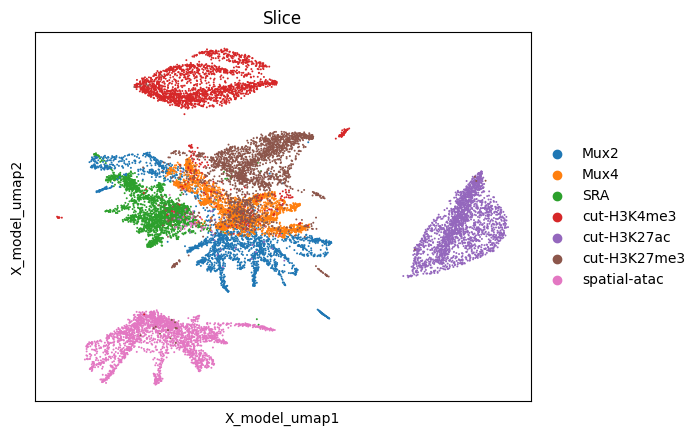

In [12]:

# ===============================
#               stage 2
# ===============================

logging.info('Concatenating training and test data...')
input_mod1 = ad.concat(
    {"train": ad_train_rna},
    axis=0, join="outer", merge="same", label="group",
    fill_value=0, index_unique="-"
)
input_mod1.uns["feature_type"] = 'GEX'

input_mod2 = ad.concat(
    {"train": ad_train_atac, "test": ad_sat_atac},
    axis=0, join="outer", merge="same", label="group",
    fill_value=0, index_unique="-"
)
input_mod2.uns["feature_type"] = 'ATAC'

input_mod3 = ad.concat(
    {"train": ad_train_4me3, 'test': ad_cut_4me3},
    axis=0, join="outer", merge="same", label="group",
    fill_value=0, index_unique="-"
)
input_mod3.uns["feature_type"] = 'H3K4me3'

input_mod4 = ad.concat(
    {"train": ad_train_27ac, 'test': ad_cut_27ac},
    axis=0, join="outer", merge="same", label="group",
    fill_value=0, index_unique="-"
)
input_mod4.uns["feature_type"] = 'H3K27ac'

input_mod5 = ad.concat(
    {"train": ad_train_27me, 'test': ad_cut_27me},
    axis=0, join="outer", merge="same", label="group",
    fill_value=0, index_unique="-"
)
input_mod5.uns["feature_type"] = 'H3K27me3'


logging.info('Reading preprocessors...')
with open(os.path.join(
       out_dir, "prep.pickle"
), "rb") as f:
    prep = pickle.load(f)
    gex_prep = prep["gex_prep"]
    other_prep1 = prep["atac_prep"]
    other_prep2 = prep["h3k4me3"]
    other_prep3 = prep["h3k27ac"]
    other_prep4 = prep["h3k27me3"]

logging.info('Preprocessing...')
gex_prep.transform(input_mod1)
other_prep1.transform(input_mod2)
other_prep2.transform(input_mod3)
other_prep3.transform(input_mod4)
other_prep4.transform(input_mod5)

logging.info('Fine-tuning model...')
scglue.models.configure_dataset(
    input_mod1, "NB", use_highly_variable=True,
    use_layer="counts", use_rep="X_pca",
    use_batch="batch", use_uid="uid"
)
scglue.models.configure_dataset(
    input_mod2, "NB", use_highly_variable=True,
    use_layer="counts", use_rep="X_lsi",
    use_batch="batch", use_uid="uid"
)
scglue.models.configure_dataset(
    input_mod3, "NB", use_highly_variable=True,
    use_layer="counts", use_rep="X_lsi",
    use_batch="batch", use_uid="uid"
)
scglue.models.configure_dataset(
    input_mod4, "NB", use_highly_variable=True,
    use_layer="counts", use_rep="X_lsi",
    use_batch="batch", use_uid="uid"
)
scglue.models.configure_dataset(
    input_mod5, "NB", use_highly_variable=True,
    use_layer="counts", use_rep="X_lsi",
    use_batch="batch", use_uid="uid"
)

with open(os.path.join(
        out_dir, "hyperparams.yaml"
), "r") as f:
    hyperparams = yaml.load(f, Loader=yaml.Loader)

logging.info('Building model...')
model = scglue.models.SCCLUEModel(
    {"gex": input_mod1, "atac": input_mod2, 
     "h3k4me3": input_mod3, "h3k27ac":input_mod4, "h3k27me3":input_mod5},
    latent_dim=hyperparams["latent_dim"],
    x2u_h_depth=hyperparams["x2u_h_depth"],
    x2u_h_dim=hyperparams["x2u_h_dim"],
    u2x_h_depth=hyperparams["u2x_h_depth"],
    u2x_h_dim=hyperparams["u2x_h_dim"],
    du_h_depth=hyperparams["du_h_depth"],
    du_h_dim=hyperparams["du_h_dim"],
    dropout=hyperparams["dropout"],
    shared_batches=False,
    random_seed=hyperparams["random_seed"]
)
# print(model.net)

logging.info('Adopting pretrained weights...')
model.adopt_pretrained_model(scglue.models.load_model(os.path.join(
    out_dir, "pretrain.dill"
)))

logging.info('Compiling model...')
model.compile(
    lam_data=hyperparams["lam_data"],
    lam_kl=hyperparams["lam_kl"],
    lam_align=hyperparams["lam_align"],
    lam_cross=hyperparams["lam_cross"],
    lam_cos=hyperparams["lam_cos"],
    normalize_u=hyperparams["normalize_u"],
    domain_weight={"gex": 1, "atac": 1, "h3k4me3": 1, "h3k27ac":1, "h3k27me3":1},
    lr=1e-3  # TODO: Fine-tuning learning rate
)

logging.info('Training model...')
model.fit(
    {"gex": input_mod1, "atac": input_mod2, 
     "h3k4me3": input_mod3, "h3k27ac":input_mod4, "h3k27me3":input_mod5},
    align_burnin=0, max_epochs=max_epochs2,
    patience=8, reduce_lr_patience=3
)

logging.info('Projecting cell embeddings...')
input_mod1.obsm["X_model"] = model.encode_data("gex", input_mod1)
input_mod2.obsm["X_model"] = model.encode_data("atac", input_mod2)
input_mod3.obsm["X_model"] = model.encode_data("h3k4me3", input_mod3)
input_mod4.obsm["X_model"] = model.encode_data("h3k27ac", input_mod4)
input_mod5.obsm["X_model"] = model.encode_data("h3k27me3", input_mod5)

def split_obsm(ads, ad_ref, key):
    split_len = np.cumsum([x.n_obs for x in ads[:-1]])
    split_obsm = np.split(ad_ref.obsm[key], split_len)
    for ad, obsm in zip(ads, split_obsm):
        ad.obsm[key] = obsm

split_obsm([ad_sra_rna, ad_mux4_rna], input_mod1, 'X_model')
split_obsm([ad_sra_atac, ad_mux4_atac, ad_sat_atac], input_mod2, 'X_model')
split_obsm([ad_mux4_4me3, ad_cut_4me3], input_mod3, 'X_model')
split_obsm([ad_mux2_27ac, ad_cut_27ac], input_mod4, 'X_model')
split_obsm([ad_mux2_27me, ad_mux4_27me, ad_cut_27me], input_mod5, 'X_model')

def avg_emb(ads, key='X_model'):
    ad_tmp = sc.AnnData(
        np.mean([x.obsm[key] for x in ads], axis=0),
        obs=ads[0].obs.copy()
    )
    ad_tmp.obsm[key] = ad_tmp.X.copy()
    return ad_tmp

ad_sra = avg_emb([ad_sra_rna, ad_sra_atac])
ad_mux2 = avg_emb([ad_mux2_27ac, ad_mux2_27me])
ad_mux4 = avg_emb([ad_mux4_rna, ad_mux4_atac, ad_mux4_4me3, ad_mux4_27me])

ad_mosaic = sc.concat([ad_sra, ad_mux2, ad_mux4, ad_sat_atac, ad_cut_4me3, ad_cut_27ac, ad_cut_27me])
ad_mosaic = get_umap(ad_mosaic, ['X_model'])

wrap_warn_plot(ad_mosaic, 'X_model_umap', ['Slice'])


In [13]:
anal_dir = f'../../../results/embeddings/CLUE/Embryo'
os.makedirs(anal_dir, exist_ok=True)

In [14]:
df = pd.DataFrame(ad_mosaic.obsm['X_model'], index=ad_mosaic.obs_names)
df.to_csv(join(anal_dir, 'df_emb.csv'))